# JOUR 3 — MATIN  
## Méthodes d’ensemble, validation croisée et optimisation

### Continuité avec le Jour 2
Nous reprenons **exactement `AI4I_J1_PREPARED.csv`**, comme au Jour 2, et la même cible de classification : **`Machine failure`**.

Objectifs :
1. rappeler le diagnostic biais / variance ;
2. comparer un arbre seul, Bagging, Random Forest, AdaBoost, Gradient Boosting et XGBoost si disponible ;
3. mettre en place une validation croisée propre ;
4. utiliser `GridSearchCV` **sans fuite de données** ;
5. garder TEST fermé jusqu’au choix final.

> **Règle :** preprocessing + modèle restent dans un `Pipeline` afin que chaque fold de CV apprenne ses transformations uniquement sur son TRAIN.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

path = Path("AI4I_J1_PREPARED.csv")
if not path.exists():
    path = Path("/mnt/data/AI4I_J1_PREPARED.csv")

df = pd.read_csv(path)
print("Dimensions :", df.shape)
display(df.head())
print("NaN :", int(df.isna().sum().sum()))


Dimensions : (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551.0,42.8,0.0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3.0,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5.0,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433.0,39.5,7.0,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9.0,0,0,0,0,0,0


NaN : 434


### Explication
On vérifie d’abord que nous travaillons sur **la même base que le Jour 2**.  
Cette continuité permet de comparer les nouveaux modèles aux modèles simples déjà étudiés, sans changer simultanément de données et d’algorithme.


# 1. Reconstituer le problème de classification

Nous conservons la même règle anti-leakage :
- `UDI` et `Product ID` sont des identifiants ;
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF` décrivent directement des modes de panne et sont exclus lorsque la cible est `Machine failure`.


In [2]:
target = "Machine failure"
excluded = ["UDI","Product ID","Machine failure","TWF","HDF","PWF","OSF","RNF"]

X = df.drop(columns=excluded)
y = df[target].astype(int)

print("Variables :", list(X.columns))
display(y.value_counts().to_frame("effectif"))
display(y.value_counts(normalize=True).round(4).to_frame("proportion"))


Variables : ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


,effectif
Machine failure,
0,9661
1,339


,proportion
Machine failure,
0,0.9661
1,0.0339


### Exemple développeur
Imaginez une API qui reçoit les mesures d’une machine et doit retourner un **risque de panne**.  
Elle ne peut pas utiliser une variable qui n’existe qu’après que la panne a été diagnostiquée. C’est exactement le réflexe anti-leakage à avoir en production.


# 2. TRAIN / VALIDATION / TEST

Nous reprenons environ **70 / 15 / 15**, avec stratification.  
VALIDATION sert à la comparaison pédagogique initiale. Ensuite, la CV permettra une estimation plus robuste sur TRAIN.


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

for nom, xx, yy in [("TRAIN",X_train,y_train),("VALID",X_val,y_val),("TEST",X_test,y_test)]:
    print(nom, xx.shape, "panne =", round(yy.mean(),4))


TRAIN (7000, 6) panne = 0.0339
VALID (1500, 6) panne = 0.034
TEST (1500, 6) panne = 0.034


# 3. Preprocessing commun dans un Pipeline

Numérique : médiane + standardisation.  
Catégoriel : modalité fréquente + One-Hot Encoding.

Même si les arbres n’exigent pas le scaling, garder un preprocessing commun facilite une comparaison cohérente et montre la logique industrielle du pipeline.


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])


# 4. Baseline : arbre seul vs ensembles

Nous comparons :
- arbre de décision ;
- Bagging ;
- Random Forest ;
- AdaBoost ;
- Gradient Boosting.

Le but n’est pas de proclamer un gagnant universel, mais d’observer **performance, recall, F1, ROC-AUC et coût**.


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(n_estimators=150, learning_rate=0.05, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=2, random_state=42
    )
}

rows, fitted = [], {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    pred = pipe.predict(X_val)
    obj = pipe.named_steps["model"]
    score = pipe.predict_proba(X_val)[:,1] if hasattr(obj,"predict_proba") else pipe.decision_function(X_val)
    rows.append({
        "modèle": name,
        "accuracy": accuracy_score(y_val,pred),
        "precision": precision_score(y_val,pred,zero_division=0),
        "recall": recall_score(y_val,pred,zero_division=0),
        "F1": f1_score(y_val,pred,zero_division=0),
        "ROC_AUC": roc_auc_score(y_val,score),
        "fit_s": elapsed
    })
    fitted[name] = pipe

comparison = pd.DataFrame(rows).sort_values("F1", ascending=False)
display(comparison.round(4))


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


,modèle,accuracy,precision,recall,F1,ROC_AUC,fit_s
1,Bagging,0.9540,0.4118,0.8235,0.5490,0.9572,8.1293
2,RandomForest,0.9767,0.8077,0.4118,0.5455,0.9666,2.0333
0,DecisionTree,0.9433,0.3509,0.7843,0.4848,0.7982,0.0865
4,GradientBoosting,0.9720,0.7143,0.2941,0.4167,0.9692,2.4118
3,AdaBoost,0.9687,0.7500,0.1176,0.2034,0.9423,2.3015


### Commenter les résultats
Demander aux étudiants :
- le meilleur F1 est-il aussi le meilleur recall ?
- quel modèle coûte le plus à entraîner ?
- une amélioration de score justifie-t-elle toujours une complexité supérieure ?

### Exemple développeur
Pour une API de maintenance temps réel, un modèle légèrement moins performant mais plus stable et plus rapide peut être préférable.


# 5. Ajouter XGBoost si la bibliothèque est disponible

XGBoost est présenté comme une extension industrielle du Gradient Boosting.  
Le notebook reste exécutable même si `xgboost` n’est pas installé.


In [7]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/48.9 MB 939.4 kB/s eta 0:00:52
   ---------------------------------------- 0.2/48.9 MB 952.6 kB/s eta 0:00:52
   ---------------------------------------- 0.2/48.9 MB 952.6 kB/s eta 0:00:52
   ---------------------------------------- 0.2/48.9 MB 692.4 kB/s eta 0:01:11
   ---------------------------------------- 0.3/48.9 MB 896.4 kB/s eta 0:00:55
   ---------------------------------------- 0.5/48.9 MB 1.2 MB/s eta 0:00:40
    --------------------------------------- 0.8/48.9 MB 1.8 MB/s eta 0:00:28
    --------------------------------------- 0.8/48.9 MB 1.9 MB/s eta 0:00:26
   - -------------------------------------- 1.4/48.9 MB 2.7 MB/s eta 0:00:18
   - ----

'DOSKEY' n'est pas reconnu en tant que commande interne
ou externe, un programme ex‚cutable ou un fichier de commandes.
DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [8]:
try:
    from xgboost import XGBClassifier

    xgb_pipe = Pipeline([
        ("prep", preprocessor),
        ("model", XGBClassifier(
            n_estimators=250,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])
    xgb_pipe.fit(X_train, y_train)
    pred = xgb_pipe.predict(X_val)
    score = xgb_pipe.predict_proba(X_val)[:,1]
    display(pd.DataFrame([{
        "modèle":"XGBoost",
        "precision":precision_score(y_val,pred,zero_division=0),
        "recall":recall_score(y_val,pred,zero_division=0),
        "F1":f1_score(y_val,pred,zero_division=0),
        "ROC_AUC":roc_auc_score(y_val,score)
    }]).round(4))
except ImportError:
    print("xgboost non installé : pip install xgboost")


,modèle,precision,recall,F1,ROC_AUC
0,XGBoost,0.8056,0.5686,0.6667,0.9728


# 6. Validation croisée

Un seul split peut être favorable ou défavorable.  
Nous utilisons une **StratifiedKFold** pour conserver la proportion de pannes dans chaque fold.

Le `Pipeline` est essentiel : l’imputation, le scaling et l’encodage sont réappris à l’intérieur de chaque fold.


In [9]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        random_state=42, n_jobs=-1
    ))
])

scores = cross_validate(
    rf_pipe, X_train, y_train, cv=cv,
    scoring={"f1":"f1", "recall":"recall", "roc_auc":"roc_auc"},
    n_jobs=-1
)

pd.DataFrame({
    "F1": scores["test_f1"],
    "Recall": scores["test_recall"],
    "ROC_AUC": scores["test_roc_auc"]
}).agg(["mean","std"]).round(4)


,F1,Recall,ROC_AUC
mean,0.5149,0.3587,0.9578
std,0.0918,0.0802,0.0159


### Lecture
La **moyenne** mesure le niveau moyen ; l’**écart-type** renseigne sur la stabilité.  
Un modèle dont le score varie fortement selon les folds mérite une investigation.


# 7. GridSearchCV — optimisation propre

Nous tunons Random Forest uniquement avec TRAIN + CV.  
**TEST reste fermé.**


In [10]:
from sklearn.model_selection import GridSearchCV

grid_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced", random_state=42, n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [150, 300],
    "model__max_depth": [None, 8, 14],
    "model__min_samples_leaf": [1, 3, 6],
    "model__max_features": ["sqrt", 0.8]
}

search = GridSearchCV(
    grid_pipe, param_grid=param_grid,
    scoring="f1", cv=cv, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)

print("Meilleurs paramètres :", search.best_params_)
print("Meilleur F1 CV :", round(search.best_score_,4))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Meilleurs paramètres : {'model__max_depth': None, 'model__max_features': 0.8, 'model__min_samples_leaf': 3, 'model__n_estimators': 150}
Meilleur F1 CV : 0.6739


### Pourquoi le TEST ne doit pas intervenir ?
Si nous regardons TEST après chaque combinaison, nous finissons par choisir indirectement le modèle qui fonctionne le mieux sur TEST. TEST n’est alors plus indépendant.


# 8. Évaluation finale sur TEST

Une fois les hyperparamètres choisis par CV, nous ouvrons TEST **une seule fois**.


Precision : 0.7955
Recall    : 0.6863
F1        : 0.7368
ROC-AUC   : 0.9664


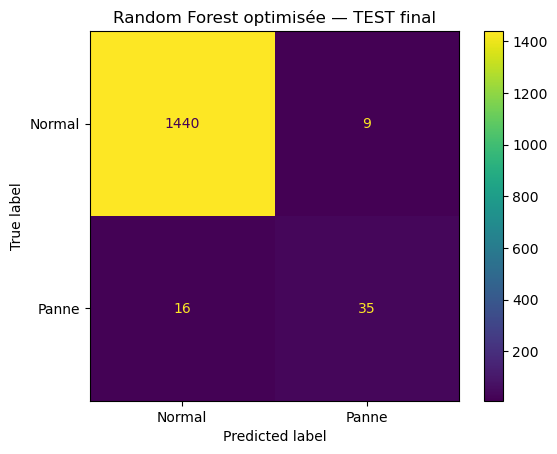

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = search.best_estimator_
pred_test = best_model.predict(X_test)
score_test = best_model.predict_proba(X_test)[:,1]

print("Precision :", round(precision_score(y_test,pred_test,zero_division=0),4))
print("Recall    :", round(recall_score(y_test,pred_test,zero_division=0),4))
print("F1        :", round(f1_score(y_test,pred_test,zero_division=0),4))
print("ROC-AUC   :", round(roc_auc_score(y_test,score_test),4))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test, display_labels=["Normal","Panne"]
)
plt.title("Random Forest optimisée — TEST final")
plt.show()


# 9. Importance des variables

Pour un modèle d’arbres, l’importance peut aider à comprendre quelles variables contribuent aux splits.  
Elle ne doit pas être interprétée comme une preuve de causalité.


,variable,importance
2,num__Rotational speed [rpm],0.337184
3,num__Torque [Nm],0.307473
4,num__Tool wear [min],0.226294
0,num__Air temperature [K],0.076169
1,num__Process temperature [K],0.041460
7,cat__Type_M,0.004952
6,cat__Type_L,0.004252
5,cat__Type_H,0.002215


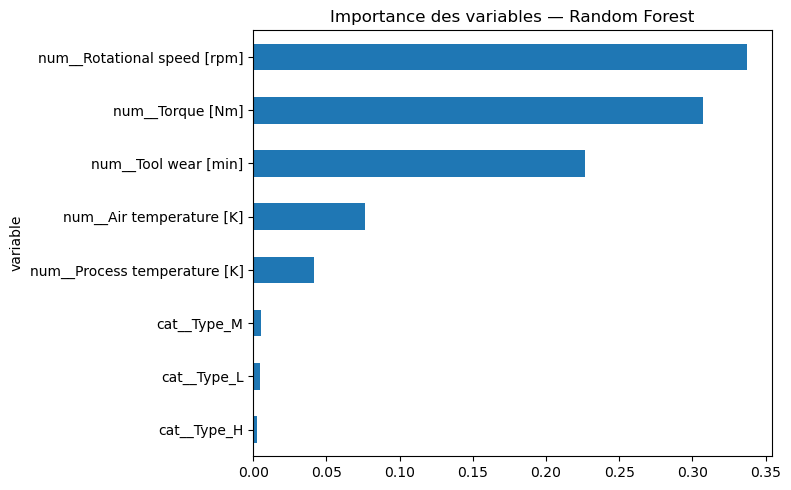

In [12]:
feature_names = best_model.named_steps["prep"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

imp = (pd.DataFrame({"variable":feature_names, "importance":importances})
       .sort_values("importance", ascending=False))

display(imp.head(12))

imp.head(12).sort_values("importance").plot(
    kind="barh", x="variable", y="importance", legend=False, figsize=(8,5)
)
plt.title("Importance des variables — Random Forest")
plt.tight_layout()
plt.show()


# SYNTHÈSE MATIN

1. Diagnostiquer biais / variance avant de changer de modèle.  
2. Bagging : paralléliser et agréger pour stabiliser.  
3. Random Forest : bagging + sous-échantillonnage des variables.  
4. Boosting : corrections séquentielles.  
5. CV : mesurer performance **et stabilité**.  
6. GridSearchCV : choisir les hyperparamètres sans toucher TEST.  
7. TEST : une seule évaluation finale.

### Transition
Cet après-midi, nous changeons de question : **que faire lorsqu’il n’existe plus de cible `y` ?**
